In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


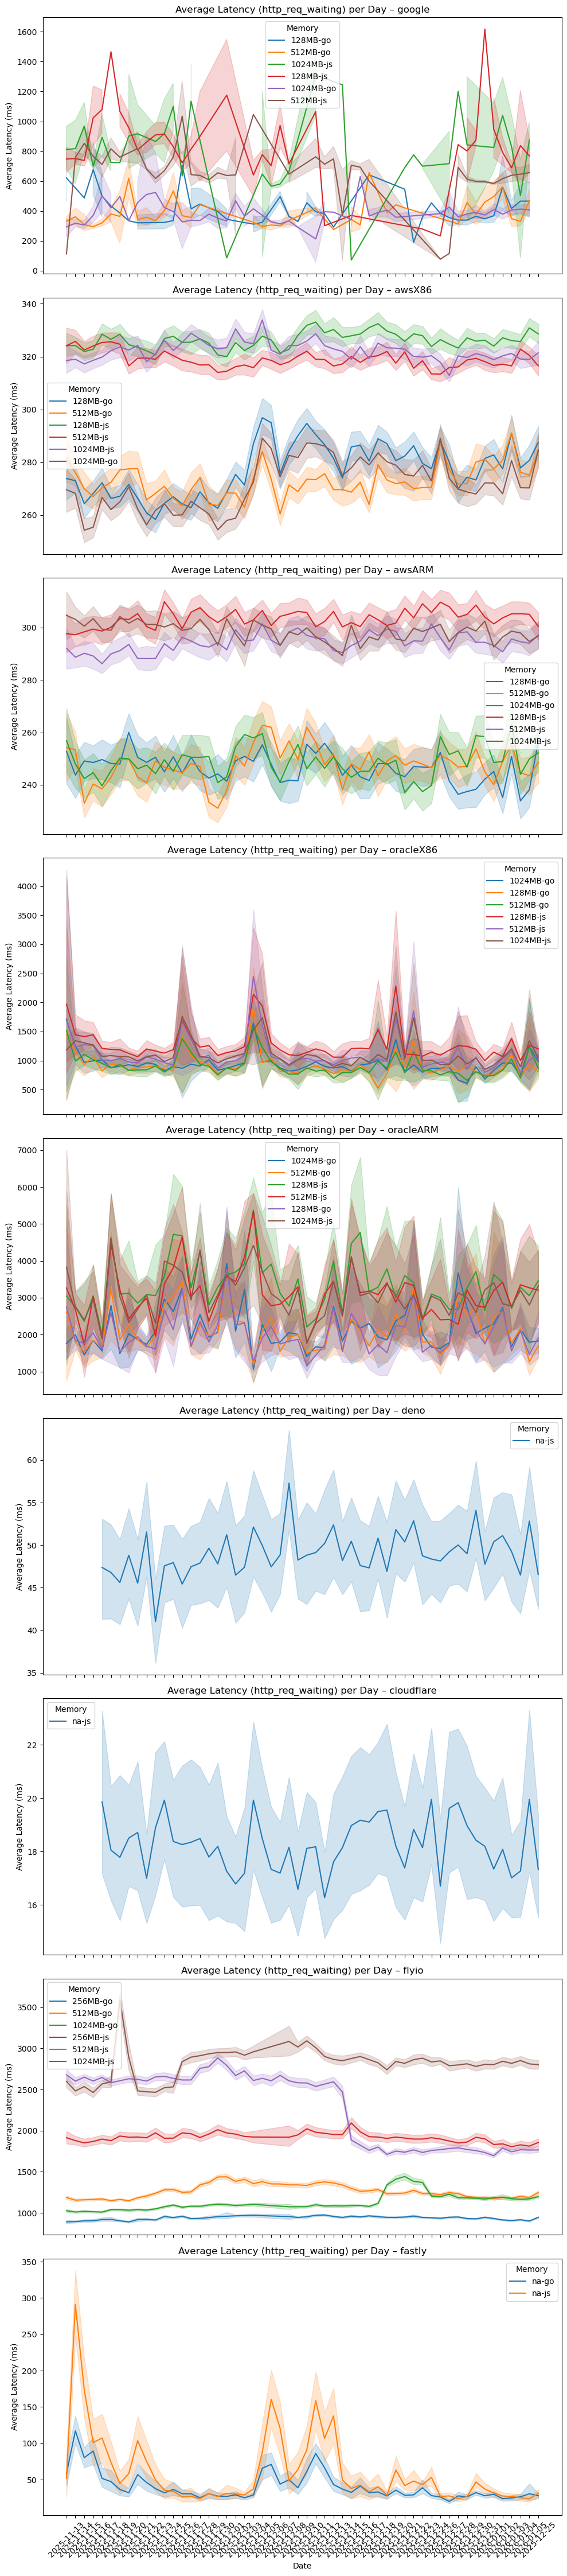

In [8]:
# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list

# Number of subplots
n_providers = len(providers)

fig, axes = plt.subplots(
    nrows=n_providers,
    ncols=1,
    figsize=(10, 5 * n_providers),
    sharex=True
)

# If only one provider, axes is not iterable
if n_providers == 1:
    axes = [axes]

for ax, provider in zip(axes, providers):
    df_provider = pd.read_sql(f"select * from data where provider = '{provider}' and experiment = 'coldstart' and cold_starts = 1", cnx)
    df_provider["date_time"] = df_provider["date_time"].str[0:10]
    
    p99 = df_provider["http_req_waiting"].quantile(0.99)
    df_provider = df_provider[df_provider["http_req_waiting"] <= p99]
    
    df_provider["hue"] = df_provider["memory"] + "-" + df_provider['language']

    sns.lineplot(
        data=df_provider,
        x="date_time",
        y="http_req_waiting",
        hue="hue",
        ax=ax
    )

    ax.set_title(f"Average Latency (http_req_waiting) per Day – {provider}")
    ax.set_ylabel("Average Latency (ms)")
    ax.legend(title="Memory")

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


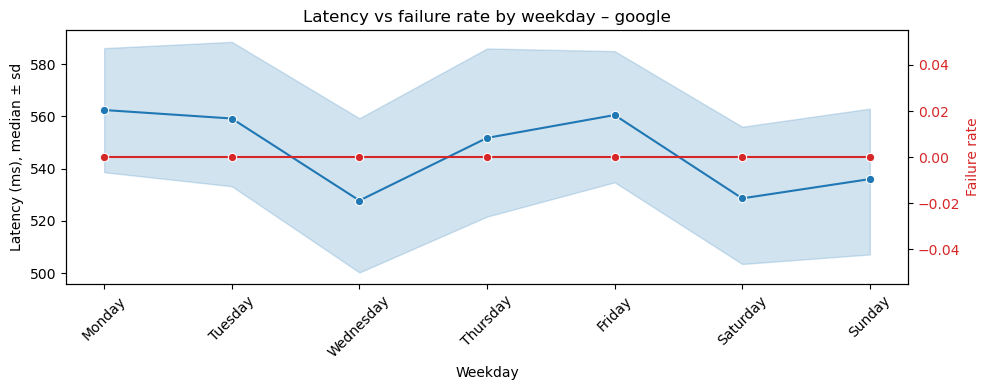

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


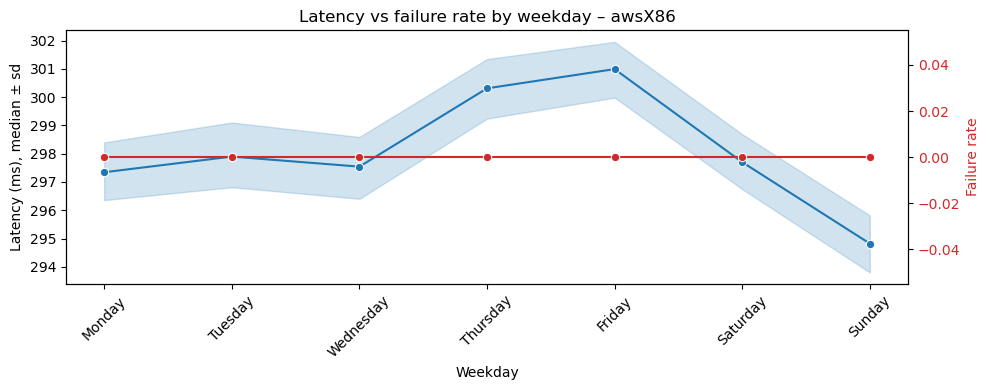

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


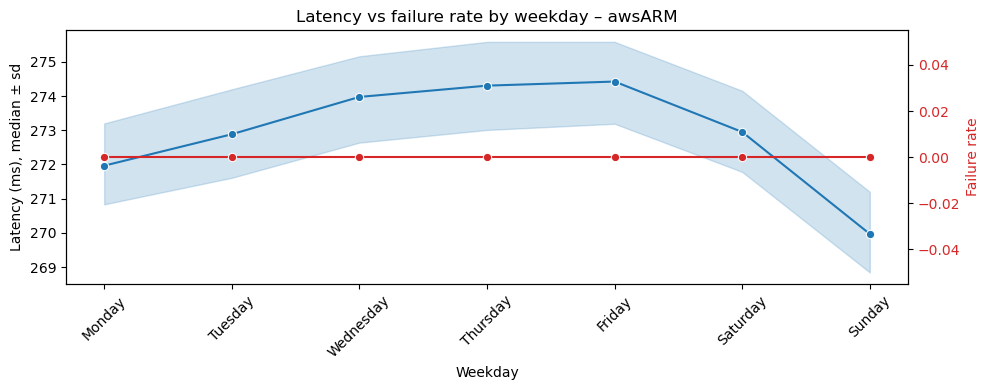

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


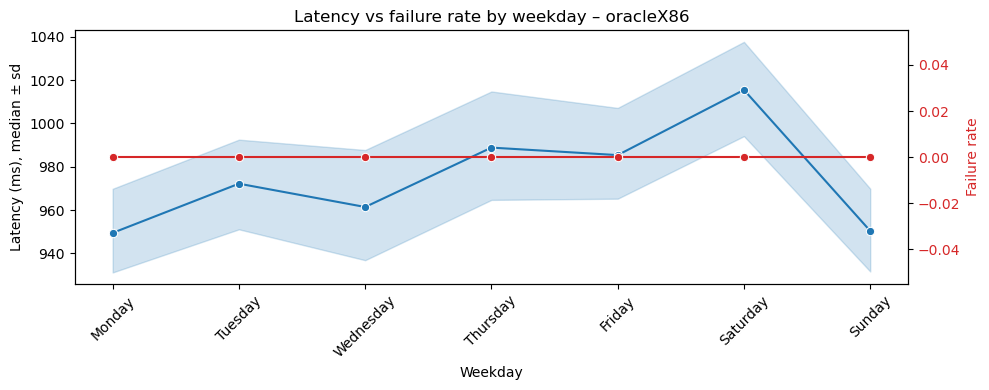

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


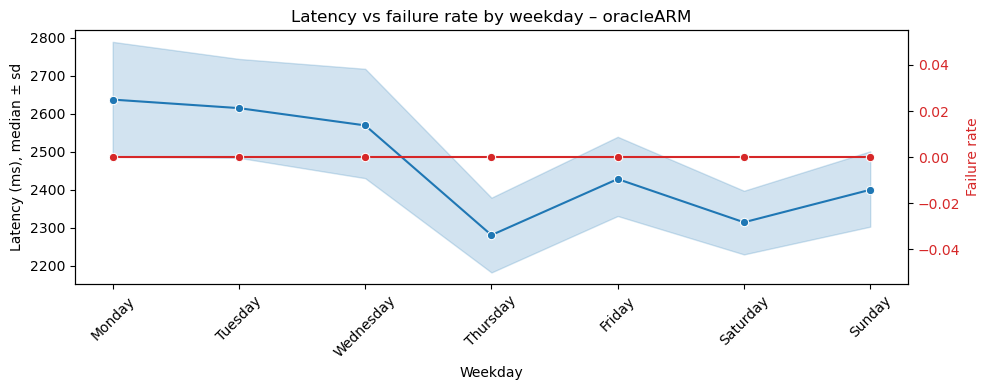

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


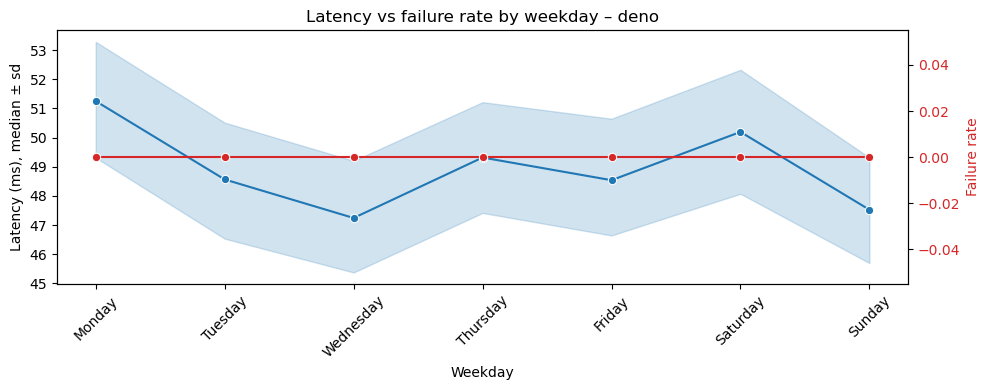

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


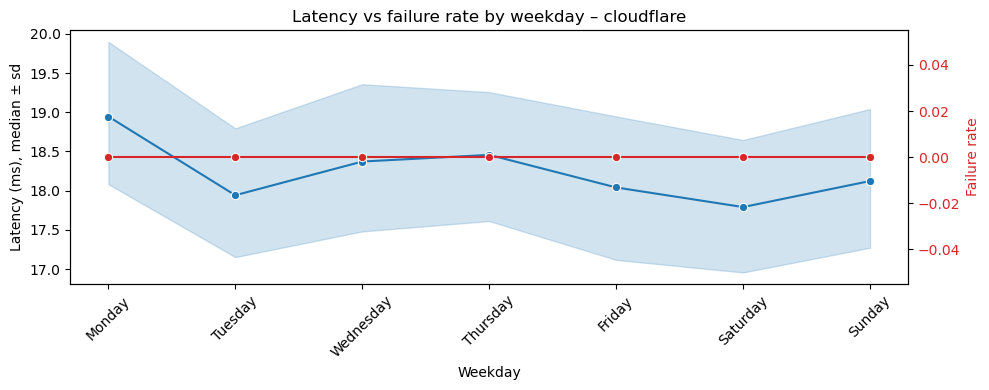

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


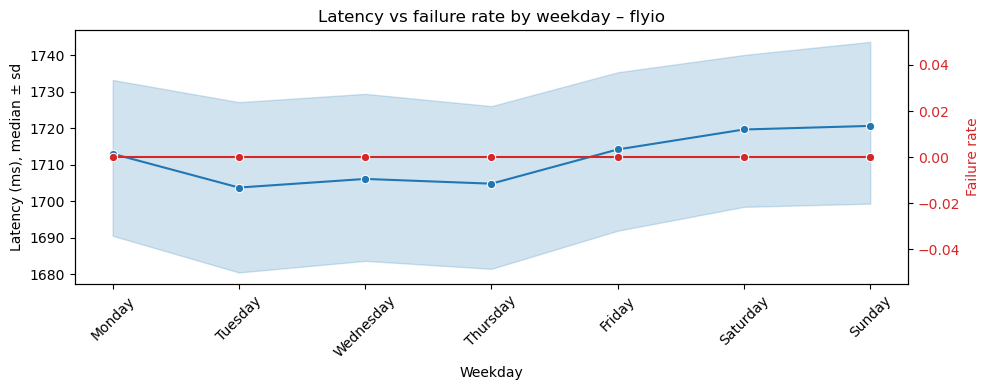

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/1898920192.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


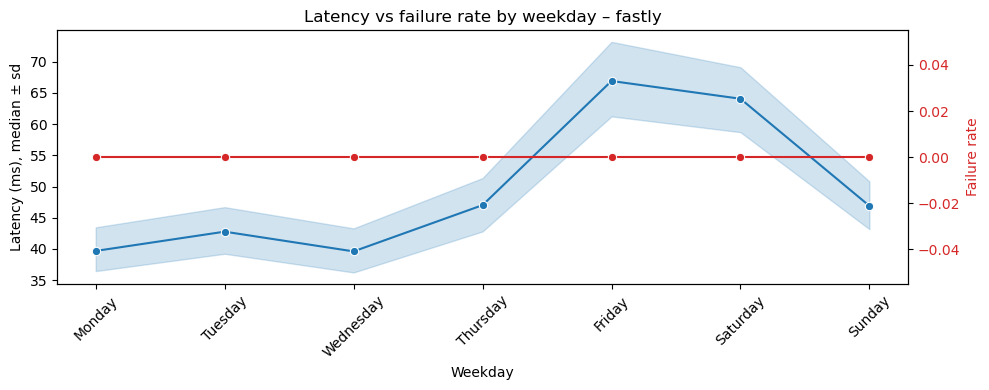

In [ ]:
# Weekday performance vs failure rate (coldstart experiment)

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for provider in providers:
    df_provider = pd.read_sql_query(
        """
        SELECT date_time, http_req_waiting, errorMessage
        FROM data
        WHERE provider = ? AND experiment = 'coldstart' AND cold_starts = 1
        """,
        cnx,
        params=[provider],
    )
    if df_provider.empty:
        continue

    # Parse date; day_name uses locale-aware weekday calculation
    df_provider["date"] = pd.to_datetime(df_provider["date_time"].str[:10], errors="coerce")
    df_provider = df_provider.dropna(subset=["date"])
    df_provider["weekday"] = df_provider["date"].dt.day_name()
    df_provider["weekday"] = pd.Categorical(df_provider["weekday"], categories=weekday_order, ordered=True)

    # Remove latency outliers
    p99 = df_provider["http_req_waiting"].quantile(0.99)
    df_provider = df_provider[df_provider["http_req_waiting"] <= p99]

    # Failure rate by weekday
    agg_fail = (
        df_provider.groupby("weekday", as_index=False)
        .agg(
            total=("http_req_waiting", "size"),
            failures=("errorMessage", lambda s: s.notna().sum()),
        )
        .sort_values("weekday")
    )
    agg_fail["fail_rate"] = (agg_fail["failures"] / agg_fail["total"]).fillna(0)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Let seaborn compute mean and variability
    sns.lineplot(
        data=df_provider,
        x="weekday",
        y="http_req_waiting",
        marker="o",
        ax=ax1,
    )
    ax1.set_title(f"Latency vs failure rate by weekday – {provider}")
    ax1.set_ylabel("Latency (ms), mean ± sd")
    ax1.set_xlabel("Weekday")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(
        data=agg_fail,
        x="weekday",
        y="fail_rate",
        marker="o",
        color="tab:red",
        ax=ax2,
    )
    ax2.set_ylabel("Failure rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.tight_layout()
    plt.show()

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


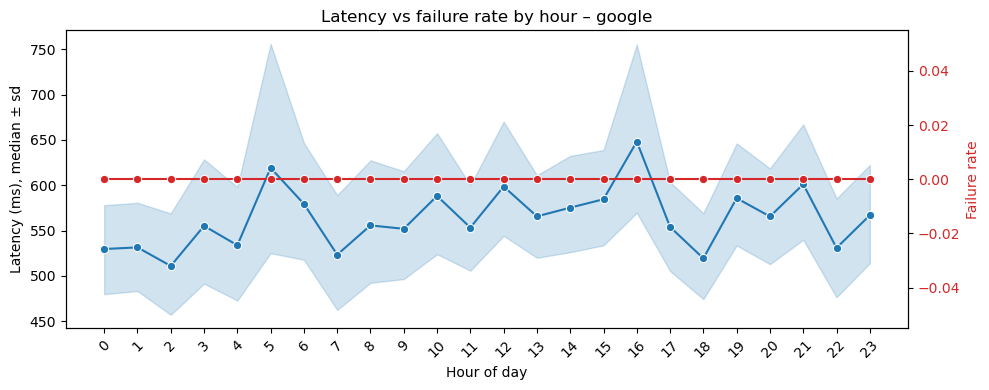

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


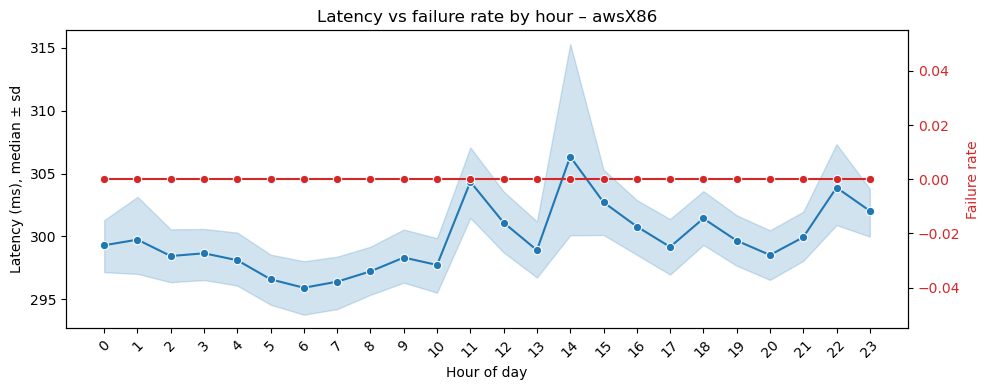

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


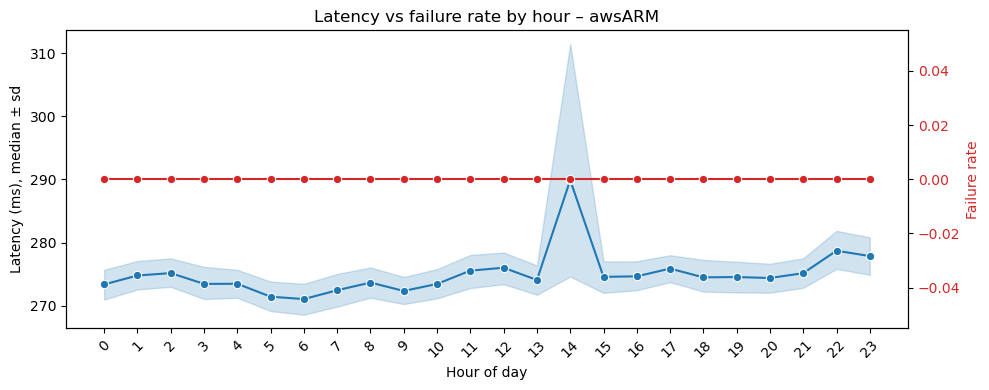

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


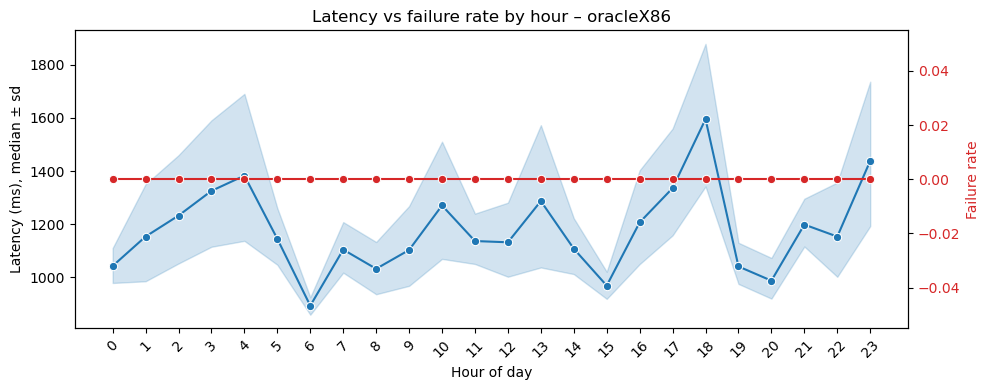

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


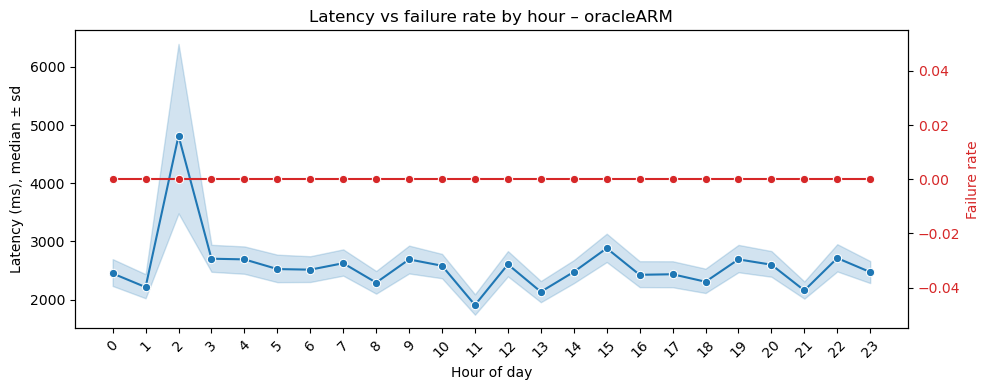

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


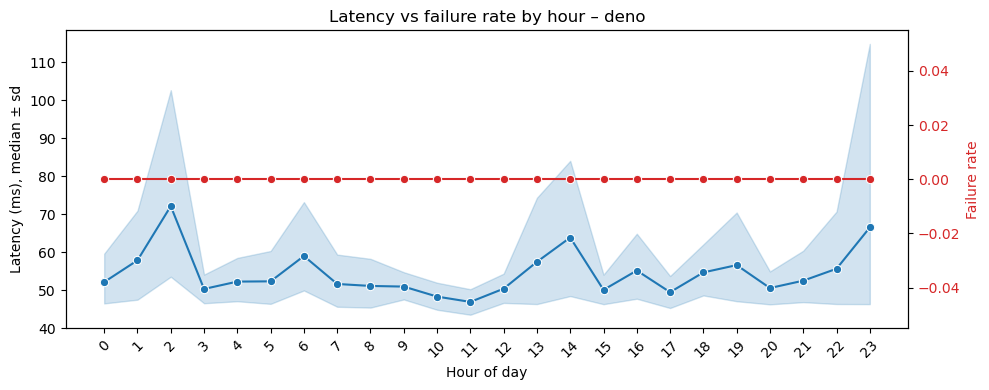

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


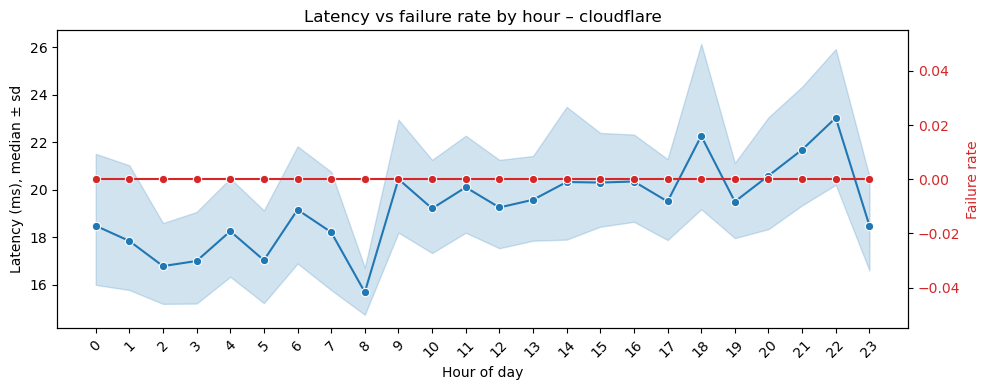

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


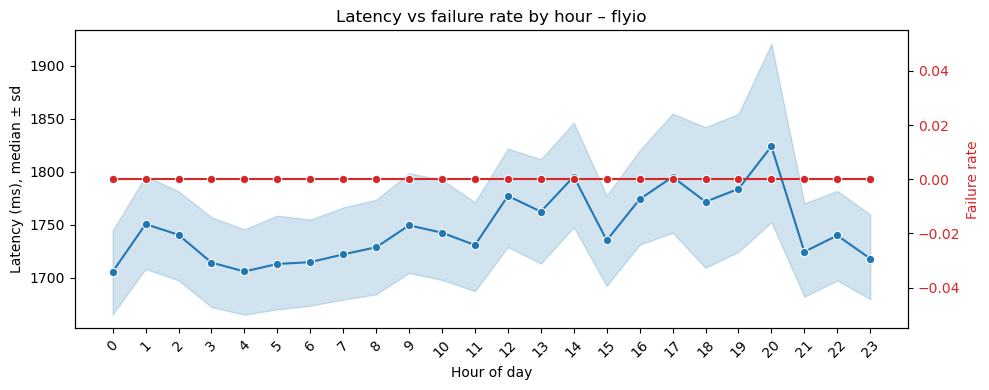

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65865/3291523417.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("hour", as_index=False)


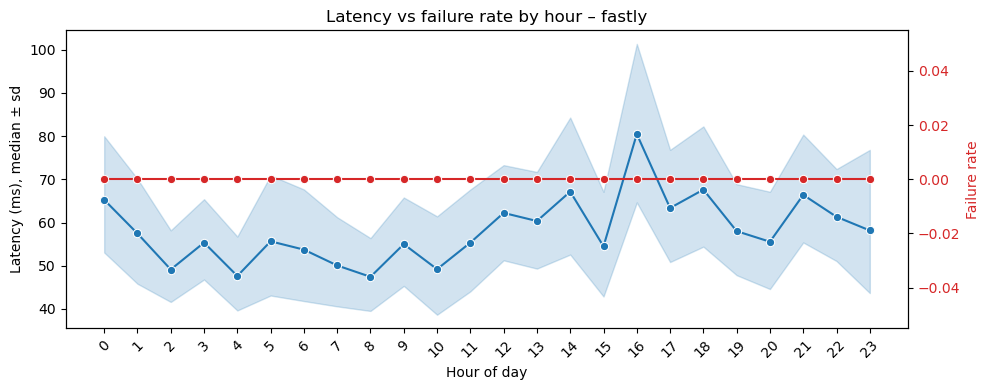

In [8]:
# Hour-of-day performance vs failure rate (coldstart experiment)

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list
hour_order = list(range(24))

for provider in providers:
    df_provider = pd.read_sql_query(
        """
        SELECT date_time, http_req_waiting, errorMessage
        FROM data
        WHERE provider = ? AND experiment = 'coldstart' AND cold_starts = 1
        """,
        cnx,
        params=[provider],
    )
    if df_provider.empty:
        continue

    # Parse timestamp safely and extract hour
    df_provider["dt"] = pd.to_datetime(df_provider["date_time"].astype(str), errors="coerce", utc=True)
    df_provider = df_provider.dropna(subset=["dt"])
    df_provider["hour"] = df_provider["dt"].dt.hour
    df_provider["hour"] = pd.Categorical(df_provider["hour"], categories=hour_order, ordered=True)

    # Remove latency outliers
    # p99 = df_provider["http_req_waiting"].quantile(0.99)
    # df_provider = df_provider[df_provider["http_req_waiting"] <= p99]

    # Failure rate by hour
    agg_fail = (
        df_provider.groupby("hour", as_index=False)
        .agg(
            total=("http_req_waiting", "size"),
            failures=("errorMessage", lambda s: s.notna().sum()),
        )
        .sort_values("hour")
    )
    agg_fail["fail_rate"] = (agg_fail["failures"] / agg_fail["total"]).fillna(0)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Let seaborn compute median and variability
    sns.lineplot(
        data=df_provider,
        x="hour",
        y="http_req_waiting",
        marker="o",
        ax=ax1,
    )
    ax1.set_title(f"Latency vs failure rate by hour – {provider}")
    ax1.set_ylabel("Latency (ms), median ± sd")
    ax1.set_xlabel("Hour of day")
    ax1.set_xticks(hour_order)
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(
        data=agg_fail,
        x="hour",
        y="fail_rate",
        marker="o",
        color="tab:red",
        ax=ax2,
    )
    ax2.set_ylabel("Failure rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.tight_layout()
    plt.show()